# Módulo 5 · Clase 5 — ¿Cuánta Vida le Queda a la Bomba?

**Machine Learning for Petroleum Engineers Using Python** · SLB Ecuador / UDLA

---

### El encargo

Operamos una flota de 100 unidades de bombeo. El equipo de intervención se
pide con anticipación, y una falla sorpresa cuesta **5 veces** más que un
cambio programado (0,3 vs 1,5 MUSD — supuestos a la vista, los pone
finanzas).

> Para cada unidad: **¿cuánta vida le queda? ¿Cuándo pido el equipo? ¿Y
> cuánto ahorra eso frente al calendario?**

### Lo que se llevan de este cuaderno

1. Bajar un dato **desde su fuente cruda** (NASA) y dejarlo usable.
2. Construir el **RUL** (vida útil remanente): el reloj que corre hacia atrás.
3. Entrenar un **gradient boosting** y afinarlo con método (malla +
   validación por unidad).
4. Explicar cada pronóstico con **valores de Shapley**.
5. Convertir pronósticos en una **política de mantenimiento**, y compararla
   contra el calendario **en dólares**.

*Acotación declarada (regla de la casa): no existe dato público de fallas de
ESP — se verificaron ocho fuentes. Usamos la flota C-MAPSS de NASA: 100
turbomáquinas gemelas corridas de sanas a la falla. Una ESP es una
turbomáquina centrífuga; el método es idéntico y los costos que usamos sí
son de ESP.*

---
## Paso 0 · El dato, desde su fuente

Nada de CSV bonito: vamos a la fuente original — el repositorio de datos de
prognosis de NASA — y lo dejamos usable nosotros. Esta es una habilidad de
la vida real: **el dato nunca llega listo**.

In [1]:
try:
    import shap
except ImportError:
    %pip install -q shap
    import shap

import io
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL_NASA = ("https://phm-datasets.s3.amazonaws.com/NASA/"
            "6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip")

/opt/homebrew/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


El zip de NASA trae **otro zip adentro**, y adentro de ese, archivos de
texto **sin encabezados**: 26 columnas separadas por espacios que hay que
nombrar leyendo el paper (Saxena et al., 2008). Bienvenidos al dato real.

In [2]:
def bajar_fd001():
    with urllib.request.urlopen(URL_NASA, timeout=120) as r:
        z = zipfile.ZipFile(io.BytesIO(r.read()))
    for nombre in z.namelist():
        if nombre.endswith("train_FD001.txt"):
            return z.read(nombre)
        if nombre.endswith(".zip"):          # el zip anidado
            z2 = zipfile.ZipFile(io.BytesIO(z.read(nombre)))
            for n2 in z2.namelist():
                if n2.endswith("train_FD001.txt"):
                    return z2.read(n2)

crudo = bajar_fd001()
print(f"{len(crudo):,} bytes bajados")
print(crudo[:120])   # miren: numeros sueltos, sin nombres

3,515,356 bytes bajados
b'1 1 -0.0007 -0.0004 100.0 518.67 641.82 1589.70 1400.60 14.62 21.61 554.36 2388.06 9046.19 1.30 47.47 521.66 2388.02 813'


In [3]:
# los nombres salen de la tabla 2 del paper: tags industriales
COLUMNAS = ["unidad", "ciclo", "op_1", "op_2", "op_3",
            "T2", "T24", "T30", "T50",      # temperaturas por estacion
            "P2", "P15", "P30",             # presiones
            "Nf", "Nc",                     # velocidades de eje
            "epr", "Ps30", "phi",
            "NRf", "NRc", "BPR", "farB",
            "htBleed", "Nf_dmd", "PCNfR_dmd",
            "W31", "W32"]                   # refrigeracion

d = pd.read_csv(io.BytesIO(crudo), sep=r"\s+", header=None,
                names=COLUMNAS)
print(d.unidad.nunique(), "unidades |", len(d), "filas")
d.head()

100 unidades | 20631 filas


,unidad,ciclo,op_1,op_2,op_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


**Verificación de reproducibilidad**: el repo del curso guarda una copia
curada de este mismo dato (`preparar_datos.py` la genera). Comprobamos que
lo que acabamos de bajar es idéntico — si NASA cambiara el archivo, este
cuaderno lo denunciaría solo.

In [4]:
URL_CSV = ("https://raw.githubusercontent.com/cmosquerat/slb-diplomado/"
           "main/datos/flota_turbomaquinas_nasa.csv")
try:
    copia = pd.read_csv(URL_CSV)
    iguales = copia.equals(d)
    print("¿copia del repo idéntica al original de NASA?", iguales)
except Exception as e:
    print("(aviso: no se pudo leer la copia del repo:", e, ")")

¿copia del repo idéntica al original de NASA? True


---
## Paso 1 · EDA: mirar antes de modelar (regla de la casa)

Primero, ¿los 21 sensores están vivos? Un sensor que nunca cambia no puede
contar ninguna historia.

In [5]:
SENSORES = ["T2", "T24", "T30", "T50", "P2", "P15", "P30", "Nf", "Nc",
            "epr", "Ps30", "phi", "NRf", "NRc", "BPR", "farB", "htBleed",
            "Nf_dmd", "PCNfR_dmd", "W31", "W32"]

desv = d[SENSORES].std().sort_values()
muertos = list(desv[desv < 1e-6].index)
vivos = [c for c in SENSORES if c not in muertos]
print(f"sensores muertos ({len(muertos)}): {', '.join(muertos)}")
print(f"sensores vivos:   {len(vivos)}")

sensores muertos (6): T2, PCNfR_dmd, Nf_dmd, epr, farB, P2
sensores vivos:   15


Seis sensores clavados — probablemente en consigna o fuera de rango en este
régimen. **Nadie lo dice en la documentación: se descubre mirando.**

Segundo: ¿cuánto viven estas máquinas?

vidas: min 128, mediana 199, max 362  (2.8 a 1)


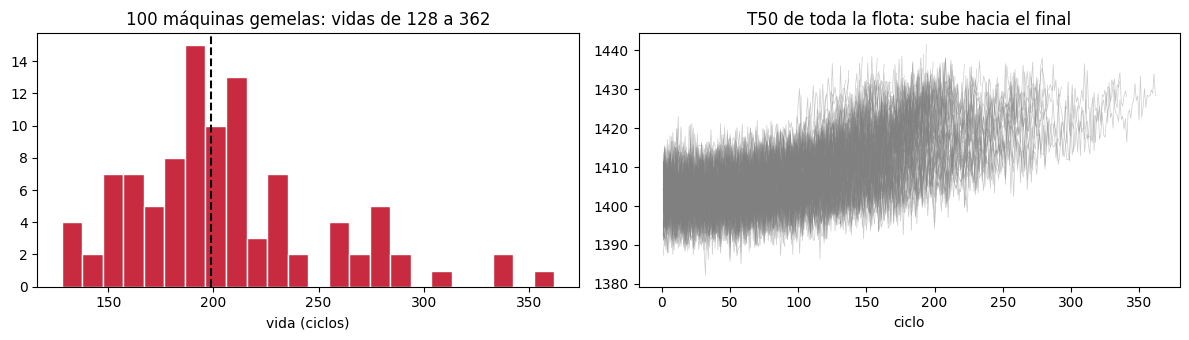

In [6]:
vida = d.groupby("unidad")["ciclo"].max().rename("vida")
print(f"vidas: min {vida.min()}, mediana {vida.median():.0f}, "
      f"max {vida.max()}  ({vida.max()/vida.min():.1f} a 1)")

fig, axs = plt.subplots(1, 2, figsize=(12, 3.5))
axs[0].hist(vida, bins=24, color="#C82B40", edgecolor="white")
axs[0].axvline(vida.median(), color="k", ls="--")
axs[0].set_title("100 máquinas gemelas: vidas de 128 a 362")
axs[0].set_xlabel("vida (ciclos)")
for u, g in d.groupby("unidad"):
    axs[1].plot(g.ciclo, g.T50, lw=0.5, color="gray", alpha=0.4)
axs[1].set_title("T50 de toda la flota: sube hacia el final")
axs[1].set_xlabel("ciclo")
plt.tight_layout()

Dos hallazgos que definen la clase:

- **Vidas de 128 a 362 ciclos** en máquinas idénticas de fábrica: un
  calendario fijo llega tarde a la mitad de la flota y bota vida en la otra
  mitad. (Las *run life* de ESP reales se dispersan igual.)
- **La degradación deja huella**: la temperatura de salida (`T50`) sube
  sistemáticamente hacia la falla. Si la huella está en los sensores, un
  modelo puede aprender a leerla.

---
## Paso 2 · Construir el reloj: la vida útil remanente (RUL)

El vocabulario, sin adorno (es el del mantenimiento predictivo en cualquier
industria):

| término | qué significa |
|---|---|
| **Run life** | La vida total del equipo: de la instalación a la falla. El número que ya manejan en ESP. |
| **RUL** | *Remaining Useful Life*: cuánta run life **falta** desde hoy. `RUL = vida − edad`. |
| **Falla funcional** | Cuando el equipo deja de cumplir su función (no cuando explota). Ahí termina el reloj. |
| **Prognosis (PHM)** | La disciplina que estima RUL desde sensores. Detectar dice «está enferma»; prognosis dice «cuánto le queda». |
| **Mantenimiento por condición** | Decidir con el estado medido de *cada* equipo — lo opuesto al calendario. |

La física que lo hace posible: la degradación mecánica es **gradual y
acumulativa** (desgaste, erosión, fatiga avanzan ciclo a ciclo) y cada
avance mueve variables termodinámicas **medibles**. Por eso el RUL se puede
estimar. Una falla súbita sin precursor no deja huella — y sin huella no
hay pronóstico.

Como estas 100 unidades ya murieron, **conocemos el RUL verdadero de cada
fila**: material perfecto para entrenar y examinar.

In [7]:
d = d.join(vida, on="unidad")
d["rul"] = d["vida"] - d["ciclo"]

d.loc[d.unidad == 1, ["ciclo", "vida", "rul"]].iloc[[0, 100, -1]]

,ciclo,vida,rul
0,1,192,191
100,101,192,91
191,192,192,0


---
## Paso 3 · De señales a tabla (la receta de la C2)

Los modelos no comen señales: comen tablas. Por cada sensor vivo, tres
miradas: el **valor de hoy**, la **media de los últimos 20 ciclos** (la foto
sin temblor) y la **pendiente** de esa media (¿se está torciendo?). Más la
edad de la unidad — el modelo debe poder usar las armas del calendario.

In [8]:
VENTANA, MITAD = 20, 10

g = d.groupby("unidad")
feats = {}
for c in vivos:
    m = g[c].transform(
        lambda s: s.rolling(VENTANA, min_periods=5).mean())
    feats[c] = d[c]
    feats[c + "_m"] = m
    feats[c + "_d"] = m - m.groupby(d["unidad"]).shift(MITAD)
feats["edad"] = d["ciclo"]
X = pd.DataFrame(feats).fillna(0)
y = d["rul"]

print(X.shape[1], "columnas:", len(vivos), "sensores x 3 + edad")

46 columnas: 15 sensores x 3 + edad


## Paso 4 · La trampa de siempre: separar por unidad

Si filas de la misma unidad caen en entrenamiento **y** examen, el modelo
«reconoce» a la máquina y el examen miente (el `GroupKFold` de la C2, el
«sacar el campo entero» de la C3). Apartamos **25 unidades completas**.

In [9]:
rng = np.random.RandomState(0)
test_u = np.sort(rng.choice(vida.index.to_numpy(), 25, replace=False))
tr = ~d["unidad"].isin(test_u)
te = d["unidad"].isin(test_u)
print("entrenan:", 100 - len(test_u), "| apartadas:", len(test_u))

entrenan: 75 | apartadas: 25


---
## Paso 5 · El rival: el calendario

El modelo tonto de hoy es **la política real de media industria**:
`RUL = mediana de vidas − edad`. Todas las bombas «duran lo mismo».

In [10]:
from sklearn.metrics import mean_absolute_error

vida_med = vida[~vida.index.isin(test_u)].median()
tonto = np.clip(vida_med - d["ciclo"], 0, None)

def marcador(pred, nombre):
    filas = {}
    for etiqueta, mask in [("toda la vida", y >= 0),
                           ("quedan 100+", y >= 100),
                           ("quedan 50-100", (y >= 50) & (y < 100)),
                           ("quedan <50", y < 50)]:
        m = te & mask
        filas[etiqueta] = mean_absolute_error(y[m], pred[m])
    return pd.Series(filas, name=nombre).round(1)

resultados = pd.DataFrame([marcador(tonto, "calendario")])
resultados

,toda la vida,quedan 100+,quedan 50-100,quedan <50
calendario,35.2,43.4,31.6,21.0


**El récord a batir: 35,2 ciclos** de error medio — y **21,0** en la zona
donde se decide (quedan <50). Peor aún: si se le hace caso, 14 de las 25
unidades revientan antes de su cita (lo veremos con dólares).

---
## Paso 6 · El modelo que faltaba: gradient boosting

El Random Forest (M3) es un **comité**: mil árboles opinan en paralelo y se
promedia. El gradient boosting es una **cadena**: cada árbol nuevo se
entrena **sobre los errores del acumulado** y aporta una corrección
chiquita. En datos tabulares (filas × columnas) es el estado del arte desde
hace una década — XGBoost (2016), LightGBM (2017) — y lo que las redes
neuronales casi nunca superan en tablas (Grinsztajn et al., 2022).

Dos perillas mandan: el **largo de la cadena** (`max_iter`) y el **tamaño
del paso** (`learning_rate`).

In [11]:
from sklearn.ensemble import HistGradientBoostingRegressor

modelo_default = HistGradientBoostingRegressor(max_iter=300,
                                               random_state=0)
modelo_default.fit(X[tr], y[tr])
pred_def = pd.Series(np.clip(modelo_default.predict(X), 0, None),
                     index=d.index)
marcador(pred_def, "boosting (default)")

toda la vida     24.8
quedan 100+      37.9
quedan 50-100    16.5
quedan <50        4.6
Name: boosting (default), dtype: float64

## Paso 7 · Afinar con método: la malla

`learning_rate=0.1` era el default. ¿Es el mejor? **No se adivina: se
examina.** Tres reglas del *hyperparameter tuning* honesto:

1. Se prueba una **malla**, no una corazonada.
2. Cada celda se califica con **validación cruzada por unidad**
   (`GroupKFold`) — máquinas nunca vistas en cada fold.
3. Todo ocurre **dentro de las 75 de entrenamiento**: las 25 apartadas no
   votan.

In [12]:
from sklearn.model_selection import GridSearchCV, GroupKFold

MALLA = {"learning_rate": [0.03, 0.1, 0.3],
         "max_depth": [2, 3, None]}

folds = list(GroupKFold(n_splits=5).split(
    X[tr], y[tr], groups=d.loc[tr, "unidad"]))

busqueda = GridSearchCV(
    HistGradientBoostingRegressor(max_iter=300, random_state=0),
    MALLA, cv=folds, scoring="neg_mean_absolute_error")
busqueda.fit(X[tr], y[tr])   # 9 celdas x 5 folds: paciencia (~2 min)

r = pd.DataFrame(busqueda.cv_results_)
tabla = r.pivot_table(index="param_max_depth",
                      columns="param_learning_rate",
                      values="mean_test_score", dropna=False)
print("MAE de validación cruzada por celda:")
print((-tabla).round(1))
print("\nmejor celda:", busqueda.best_params_,
      f"(MAE CV {-busqueda.best_score_:.1f})")

MAE de validación cruzada por celda:
param_learning_rate  0.03  0.10  0.30
param_max_depth                      
2.0                  24.5  24.6  25.6
3.0                  24.1  24.6  25.8
NaN                  24.1  24.3  25.6

mejor celda: {'learning_rate': 0.03, 'max_depth': None} (MAE CV 24.1)


**La lección incómoda**: la malla entera vive entre 24,1 y 25,8 ciclos, y
la celda ganadora le gana al default por **0,2**. El afinado fino compra
poco — los saltos grandes los dieron el modelo correcto y los features
correctos. **Afinen al final, no primero.**

In [13]:
modelo = busqueda.best_estimator_
pred = pd.Series(np.clip(modelo.predict(X), 0, None), index=d.index)

pd.DataFrame([marcador(tonto, "calendario"),
              marcador(pred, "boosting (afinado)")])

,toda la vida,quedan 100+,quedan 50-100,quedan <50
calendario,35.2,43.4,31.6,21.0
boosting (afinado),24.4,37.0,16.3,5.0


**Léanlo por zonas**: con la unidad joven (100+ ciclos por delante) casi
empatan — sin degradación visible no hay nada que leer; *el modelo no
adivina el futuro, reconoce el deterioro presente*. Pero en la **zona de la
decisión** (quedan <50): calendario 21,0 vs boosting **5,0**. Cuatro veces
mejor justo donde vive la plata.

---
## Paso 8 · El porqué: valores de Shapley

Un pronóstico sin porqué no se firma. **Shapley** (Nobel de economía 2012)
resolvió cómo repartir *justo* el premio de un equipo entre sus jugadores:
medir cuánto cambia el resultado con y sin cada uno, en todas las
alineaciones, y promediar. Aplicado al modelo: ¿cuánto empujó **cada
columna** este pronóstico, respecto del promedio de la flota? Para árboles
se calcula exacto y rápido (TreeSHAP).

unidad 87: media de la flota 108 -> pronóstico 42 ciclos (RUL real: 50)


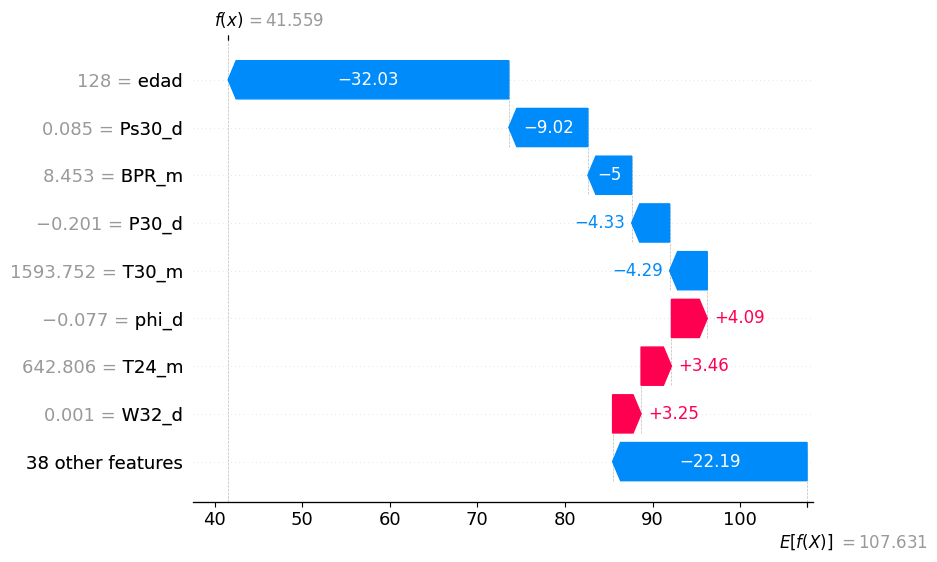

In [14]:
explicador = shap.TreeExplainer(modelo)

# la unidad de test con menos vida por delante en su "foto de hoy"
foto = []
for u in test_u:
    corte = int(vida.loc[u] * 0.72)
    f = d[(d.unidad == u) & (d.ciclo == corte)]
    if len(f):
        foto.append(f.index[0])
foto = pd.Index(foto)
p_foto = pred.loc[foto]
peor = foto[np.argsort(p_foto.values)[0]]

sv = explicador(X.loc[[peor]])
print(f"unidad {int(d.loc[peor,'unidad'])}: media de la flota "
      f"{sv.base_values[0]:.0f} -> pronóstico "
      f"{sv.base_values[0]+sv.values[0].sum():.0f} ciclos "
      f"(RUL real: {int(d.loc[peor,'rul'])})")
shap.plots.waterfall(sv[0], max_display=9)

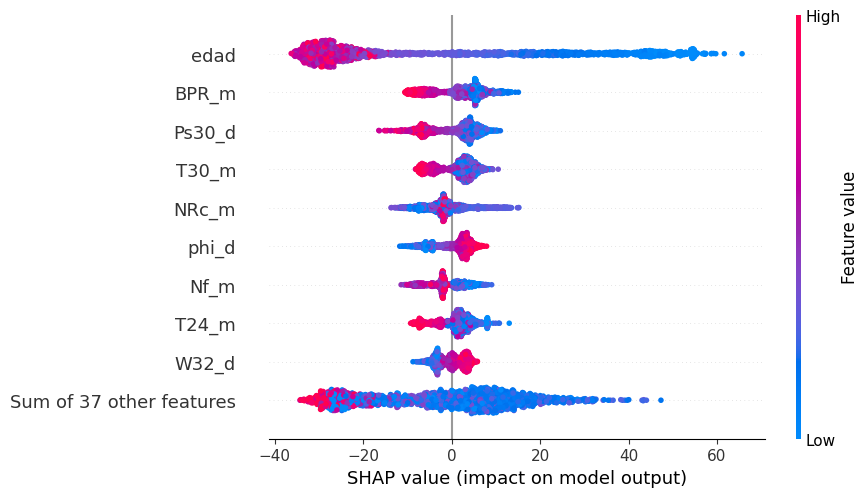

In [15]:
# y la vista global: 2.000 pronosticos de las 25 unidades apartadas
rng2 = np.random.RandomState(2)
muestra = np.sort(rng2.choice(np.where(te)[0], 2000, replace=False))
sv_g = explicador(X.iloc[muestra])
shap.plots.beeswarm(sv_g, max_display=10)

**La letra chica (léanla siempre)**: Shapley reparte el pronóstico **del
modelo**, no la culpa física. Sensores correlacionados se roban crédito
entre sí. La prueba con nuestros números — el waterfall le dio a la *edad*
el pedazo más grande; veamos si el modelo la *necesitaba*:

In [16]:
X_se = X.drop(columns=["edad"])
sin_edad = HistGradientBoostingRegressor(max_iter=300, random_state=0,
                                         **busqueda.best_params_)
sin_edad.fit(X_se[tr], y[tr])
pred_se = pd.Series(np.clip(sin_edad.predict(X_se), 0, None),
                    index=d.index)
pd.DataFrame([marcador(pred, "con edad"),
              marcador(pred_se, "sin edad (ablación)")])

,toda la vida,quedan 100+,quedan 50-100,quedan <50
con edad,24.4,37.0,16.3,5.0
sin edad (ablación),24.2,35.4,18.8,5.3


Sin la edad, el error casi no cambia: la información de la edad **también
vive en los sensores** (una máquina vieja *se ve* vieja). Shapley dice qué
usó el modelo; la **ablación** dice qué necesitaba. Con las dos, la
explicación aguanta una reunión hostil.

---
## Paso 9 · El error tiene dirección: del P50 al P10

Decir «quedan 60» cuando quedaban 20 → bomba muerta esperando equipo
(1,5 MUSD). Decir «quedan 20» cuando quedaban 60 → vida desperdiciada
(mucho más barato). El promedio (P50) ignora esa asimetría; la decisión no
puede. El mismo boosting, con pérdida de cuantil, aprende la versión
**prudente** del reloj:

In [17]:
p10 = HistGradientBoostingRegressor(loss="quantile", quantile=0.10,
                                    max_iter=300, random_state=0,
                                    **busqueda.best_params_)
p10.fit(X[tr], y[tr])
pred10 = pd.Series(np.clip(p10.predict(X), 0, None), index=d.index)

cobertura = float((y[te] >= pred10[te]).mean())
print(f"cobertura del P10 en las 25 apartadas: {cobertura*100:.0f} % "
      "(nominal: 90 %)")

cobertura del P10 en las 25 apartadas: 83 % (nominal: 90 %)


83 % contra 90 nominal: **un poco optimista, y se declara** — igual que
auditamos la banda en la C3 (76 vs 80). Por eso la regla de decisión lleva
colchón.

---
## Paso 10 · La política, y las cuatro compitiendo en dólares

La regla de decisión completa — noten que cada número tiene dueño:

1. Cada ciclo, mirar el **P10** del RUL de cada unidad *(la estadística)*.
2. Si baja de **20 ciclos** → pedir el equipo hoy *(20 = movilización + colchón: finanzas)*.
3. El cambio ocurre **15 ciclos después** *(lo que tarda el equipo: logística)*.

La simulación es una función — y queda parametrizada para Su Turno:

In [18]:
COSTO_PLAN, COSTO_EMERG = 0.3, 1.5   # MUSD, supuestos a la vista
UMBRAL, MOVIL = 20, 15

def costo_politica(cortes, c_plan=COSTO_PLAN, c_emerg=COSTO_EMERG):
    emerg, desp, ciclos, costo = 0, [], 0, 0.0
    for u in test_u:
        v, c = vida.loc[u], cortes[u]
        if c >= v:              # no llego a tiempo: revienta
            emerg += 1; ciclos += v; costo += c_emerg; desp.append(0)
        else:                   # cambio programado
            ciclos += c; costo += c_plan; desp.append(v - c)
    return dict(emergencias=emerg,
                desperdicio_mediano=float(np.median(desp)),
                MUSD_por_1000_ciclos=round(1000 * costo / ciclos, 2))

def cortes_modelo(predq, umbral=UMBRAL, movil=MOVIL):
    cortes = {}
    for u in test_u:
        m = d["unidad"] == u
        aviso = d.loc[m & (predq < umbral), "ciclo"]
        cortes[u] = aviso.iloc[0] + movil if len(aviso) else np.inf
    return cortes

vidas_tr = vida[~vida.index.isin(test_u)]
politicas = {
    "correr a la falla": {u: np.inf for u in test_u},
    "calendario (mediana)": {u: vidas_tr.median() for u in test_u},
    "calendario conservador": {u: vidas_tr.quantile(0.10)
                               for u in test_u},
    "modelo (P10 < 20, +15)": cortes_modelo(pred10),
}
pd.DataFrame({k: costo_politica(v) for k, v in politicas.items()}).T

,emergencias,desperdicio_mediano,MUSD_por_1000_ciclos
correr a la falla,25.0,0.0,7.18
calendario (mediana),14.0,0.0,5.21
calendario conservador,1.0,41.0,2.26
"modelo (P10 < 20, +15)",0.0,5.0,1.49


**La cuenta final**: correr a la falla 7,18; el calendario común 5,21 (¡14
emergencias!); el conservador evita las sorpresas pero bota 41 ciclos de
vida por unidad: 2,26. El modelo: **0 emergencias, 5 ciclos botados, 1,49 —
un 34 % más barato que el mejor calendario posible**.

Ese es el párrafo para gerencia: no «MAE 24,4», sino *«de 14 fallas
sorpresa a cero, botando 5 ciclos por bomba en vez de 41: 34 % menos costo
por ciclo corrido»*.

In [19]:
# la lista del mes: la foto de hoy, ordenada por el P10 (los 5 primeros
# van a la orden de trabajo -- cada uno con su porque de Shapley)
lista = pd.DataFrame({
    "unidad": d.loc[foto, "unidad"].values,
    "P10_rul": pred10.loc[foto].round(0).values,
    "rul_real": d.loc[foto, "rul"].values,
}).sort_values("P10_rul").reset_index(drop=True)
lista.head(8)

,unidad,P10_rul,rul_real
0,23,36.0,48
1,87,39.0,50
2,74,41.0,47
3,14,45.0,51
4,34,45.0,55
5,93,46.0,44
6,4,47.0,53
7,63,48.0,49


---
## Su Turno · Firmen su propia regla (20 min)

Ustedes **no** operan el campo de la clase: operan el **escenario B — campo
en tierra**. Hay equipo de workover cerca:

| supuesto | clase (offshore) | **ustedes (tierra)** |
|---|---|---|
| cambio programado | 0,3 MUSD | **0,08 MUSD** |
| falla en operación | 1,5 MUSD | **0,16 MUSD** (solo 2×, no 5×) |
| movilización | 15 ciclos | **5 ciclos** |

**Primer paso, resuelto** (el andamiaje de la casa): la política de la
clase, con sus costos:

In [20]:
# paso 1 (resuelto): la regla de la clase, con los costos de ustedes
costo_politica(cortes_modelo(pred10, umbral=20, movil=5),
               c_plan=0.08, c_emerg=0.16)

{'emergencias': 0,
 'desperdicio_mediano': 15.0,
 'MUSD_por_1000_ciclos': np.float64(0.42)}

**Ahora ustedes** (completen las celdas):

1. Corran las **cuatro políticas** con sus costos. ¿Sigue ganando el
   modelo? ¿Por cuánto?
2. Prueben umbrales de aviso **10, 20 y 30** y quédense con el más barato.
   ¿Les dio distinto que a la clase? ¿Por qué?
3. Escriban el párrafo **«Así Sí»** para su gerente, con *sus* números.

*Pista: cuando la sorpresa cuesta casi lo mismo que el plan, la prudencia
deja de ser gratis. No busquen la respuesta de la clase — busquen la de su
campo.*

In [21]:
# paso 2: las cuatro politicas con SUS costos
# (ayuda: copien el diccionario `politicas` de arriba y cambien c_plan
#  y c_emerg en la llamada)
resultados_b = pd.DataFrame({
    k: costo_politica(v, c_plan=0.08, c_emerg=0.16)
    for k, v in politicas.items()}).T
resultados_b

,emergencias,desperdicio_mediano,MUSD_por_1000_ciclos
correr a la falla,25.0,0.0,0.77
calendario (mediana),14.0,0.0,0.67
calendario conservador,1.0,41.0,0.54
"modelo (P10 < 20, +15)",0.0,5.0,0.40


In [22]:
# paso 3: el umbral optimo para SU campo
for umbral in [10, 20, 30]:
    r = costo_politica(cortes_modelo(pred10, umbral=umbral, movil=5),
                       c_plan=0.08, c_emerg=0.16)
    print(f"umbral {umbral}: {r}")

# TODO: con el mas barato, escriban el parrafo "Asi Si" para su gerente.

umbral 10: {'emergencias': 0, 'desperdicio_mediano': 5.0, 'MUSD_por_1000_ciclos': np.float64(0.39)}
umbral 20: {'emergencias': 0, 'desperdicio_mediano': 15.0, 'MUSD_por_1000_ciclos': np.float64(0.42)}
umbral 30: {'emergencias': 0, 'desperdicio_mediano': 29.0, 'MUSD_por_1000_ciclos': np.float64(0.45)}


**La lección del ejercicio** (léanla después de intentarlo): mismo modelo,
mismos pronósticos, **otra estructura de costos → otra política óptima**.
La decisión nunca estuvo dentro del modelo: el modelo pone el pronóstico,
el negocio pone el umbral. Quien entiende eso no vuelve a pedir «el mejor
modelo» — pide **el mejor sistema de decisión**.

---
## Para llevar (opcional) · Un tablero de explicabilidad completo

La librería `explainerdashboard` monta un tablero interactivo (Shapley por
unidad, importancias, dependencias, qué-pasa-si) sobre cualquier modelo de
scikit-learn. Para probarlo en Colab: cambien el flag y corran la celda
(instala Dash; tarda un par de minutos).

In [23]:
QUIERO_DASHBOARD = False   # True para probarlo (idealmente en Colab)

if QUIERO_DASHBOARD:
    %pip install -q explainerdashboard
    from explainerdashboard import (RegressionExplainer,
                                    ExplainerDashboard)
    sub = np.sort(rng2.choice(np.where(te)[0], 1000, replace=False))
    ex = RegressionExplainer(modelo, X.iloc[sub], y.iloc[sub])
    ExplainerDashboard(ex, title="Flota RUL",
                       shap_interaction=False).run(mode="inline")

---
## Lo que vimos → lo que decidimos

| lo que vimos | lo que decidimos con eso |
|---|---|
| Vidas de 128 a 362 en máquinas gemelas | El calendario ingenuo pierde: 14 sorpresas de 25 |
| La degradación deja huella termodinámica | Construir el RUL: el reloj que corre hacia atrás |
| Boosting: la cadena que corrige | 5 ciclos de error en la zona de decisión (4× mejor) |
| La malla afinó con método (GroupKFold) | …y compró 0,2 ciclos: afinar al final, no primero |
| Shapley + ablación | Órdenes de trabajo con porqué — y con letra chica |
| P10 + regla de tres números | 0 emergencias, 34 % menos costo que el mejor calendario |

**Resultados negativos, en voz alta**: con la unidad joven el modelo no
sabe más que el calendario; el afinado compró 0,2 ciclos; el P10 prometió
90 % y cumplió 83 %.

### Referencias

- Saxena, Goebel, Simon & Eklund (2008). *Damage Propagation Modeling for
  Aircraft Engine Run-to-Failure Simulation*, PHM08. Dataset C-MAPSS,
  NASA PCoE — dominio público.
- Lundberg & Lee (2017). *A Unified Approach to Interpreting Model
  Predictions* (SHAP), NeurIPS.
- Grinsztajn, Oyallon & Varoquaux (2022). *Why do tree-based models still
  outperform deep learning on tabular data?*, NeurIPS.

*Todas las cifras de este cuaderno deben coincidir exactamente con las de
`figuras.py`. Si no coinciden, es un error nuestro y queremos saberlo.*